In [118]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
from functools import reduce
import ee
import time

In [119]:
# Load data
df_weather = pd.read_csv(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_admin2_ERA5_timeseries(in).csv")
df_ndvi = pd.read_csv(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_admin2_VI_timeseries_GLAD.csv")

In [120]:
df_weather.head()

,date,ADMIN_NAME,PCODE,temperature_2m,volumetric_soil_water_layer_1,total_precipitation_sum,temperature_2m_min,temperature_2m_max
0,01/01/1990,Chibombo,ZM2011A20101,292.492410,0.441992,0.033335,291.631105,293.867263
1,01/01/1990,Kabwe,ZM2011A20105,292.493364,0.430936,0.020226,291.450015,293.891872
2,01/01/1990,Kapiri Mposhi,ZM2011A20106,292.408031,0.424922,0.030994,291.245291,294.894839
3,01/01/1990,Mkushi,ZM2011A20110,293.315206,0.422842,0.025818,291.578104,296.424434
4,01/01/1990,Serenje,ZM2011A20111,293.379198,0.419945,0.016667,291.278934,296.627077


In [121]:
df_ndvi.head()

,date,GLAD_year,ADMIN_NAME,PCODE,NDVI_mean,NDVI_median,NDVI_mode,EVI_mean,EVI_median,EVI_mode
0,18-02-00,2003,Chibombo,ZM2011A20101,0.561508,0.580193,0.619067,0.378623,0.384674,0.388794
1,18-02-00,2003,Kabwe,ZM2011A20105,0.562254,0.580710,0.631446,0.395002,0.380832,0.388794
2,18-02-00,2003,Kapiri Mposhi,ZM2011A20106,0.543531,0.560810,0.724795,0.368682,0.376884,0.376884
3,18-02-00,2003,Mkushi,ZM2011A20110,0.544423,0.595528,0.650417,0.372618,0.388788,0.388788
4,18-02-00,2003,Serenje,ZM2011A20111,0.453161,0.428063,0.673860,0.312187,0.293411,0.263507


In [122]:
# Clean column names
df_weather.columns = df_weather.columns.str.strip().str.upper()
df_ndvi.columns = df_ndvi.columns.str.strip().str.upper()

# Standardize district column
def fix_dist(df):
    for col in df.columns:
        if 'ADM' in col or 'DISTRICT' in col:
            return df.rename(columns={col: 'DISTRICT'})
    return df

df_weather = fix_dist(df_weather)
df_ndvi = fix_dist(df_ndvi)

# Parse dates
df_weather['DATE_DT'] = pd.to_datetime(df_weather['DATE'], dayfirst=True, errors='coerce')
df_ndvi['DATE_DT'] = pd.to_datetime(df_ndvi['DATE'], dayfirst=True, errors='coerce')

# Extract year and month
df_weather['YEAR'] = df_weather['DATE_DT'].dt.year
df_weather['MONTH'] = df_weather['DATE_DT'].dt.month

df_ndvi['YEAR'] = df_ndvi['DATE_DT'].dt.year
df_ndvi['MONTH'] = df_ndvi['DATE_DT'].dt.month

# Standardize district text
df_weather['DISTRICT'] = df_weather['DISTRICT'].astype(str).str.strip().str.upper()
df_ndvi['DISTRICT'] = df_ndvi['DISTRICT'].astype(str).str.strip().str.upper()

C:\Users\flavi\AppData\Local\Temp\ipykernel_17052\1663141108.py:17: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [123]:
# Merge only common district-year-month rows
merged_df = pd.merge(
    df_weather,
    df_ndvi,
    on=['DISTRICT', 'YEAR', 'MONTH'],
    how='inner',
    suffixes=('_WEATHER', '_NDVI')
)

merged_df.to_csv('Zambia_Master_Drought_Table.csv', index=False)
print("Join Successful! Master table created.")

# Keep only growing season months
growing_season = merged_df[merged_df['MONTH'].isin([11, 12, 1, 2, 3, 4])].copy()

Join Successful! Master table created.


In [124]:
# ==========================================
# 2. CALCULATE DROUGHT INDICES (SSI & VHI)
# ==========================================

# Calculate SSI (Standardized Soil Moisture Index) - Z-Score per district
stats_sm = seasonal_summary.groupby('DISTRICT')['VOLUMETRIC_SOIL_WATER_LAYER_1'].agg(['mean', 'std']).reset_index()
seasonal_summary = seasonal_summary.merge(stats_sm, on='DISTRICT')
seasonal_summary['SSI'] = (seasonal_summary['VOLUMETRIC_SOIL_WATER_LAYER_1'] - seasonal_summary['mean']) / seasonal_summary['std']

# Calculate VHI (Vegetation Health Index)
# VCI = (NDVI - min) / (max - min)
ndvi_stats = seasonal_summary.groupby('DISTRICT')['NDVI_MEAN'].agg(['min', 'max']).reset_index().rename(columns={'min':'n_min', 'max':'n_max'})
seasonal_summary = seasonal_summary.merge(ndvi_stats, on='DISTRICT')
seasonal_summary['VCI'] = (seasonal_summary['NDVI_MEAN'] - seasonal_summary['n_min']) / (seasonal_summary['n_max'] - seasonal_summary['n_min']) * 100

# TCI = (LST_max - LST) / (LST_max - LST_min) -> Using TEMP_2M as proxy for LST
lst_stats = seasonal_summary.groupby('DISTRICT')['TEMPERATURE_2M'].agg(['min', 'max']).reset_index().rename(columns={'min':'t_min', 'max':'t_max'})
seasonal_summary = seasonal_summary.merge(lst_stats, on='DISTRICT')
seasonal_summary['TCI'] = (seasonal_summary['t_max'] - seasonal_summary['TEMPERATURE_2M']) / (seasonal_summary['t_max'] - seasonal_summary['t_min']) * 100

seasonal_summary['VHI'] = 0.5 * seasonal_summary['VCI'] + 0.5 * seasonal_summary['TCI']

KeyError: 'mean'

In [ ]:
# 3. GEOSPATIAL MERGE & MAPPING

# Load your Zambia shapefile (Ensure it is the Level 2/District file)
zambia_shp = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_Administrative_Boundaries_Districts_2020_-7037893626831916322\NSDI_Zambia_Districts_2022.shp")
#zambia_shp['DISTRICT'] = zambia_shp['ADM2_EN'].str.upper() # Standardize names to match CSV

# Merge geometry with data
gdf_merged = zambia_shp.merge(seasonal_summary, on='DISTRICT')

# Ensure WGS84 for Plotly
gdf_merged = gdf_merged.to_crs(epsg=4326)
gdf_merged['geometry'] = gdf_merged.geometry.simplify(0.01)

# Create the Animated Map
fig = px.choropleth(
    gdf_merged,
    geojson=gdf_merged.__geo_interface__,
    locations='DISTRICT',      # Use the column name, not the index
    featureidkey="properties.DISTRICT", 
    color="SSI",
    animation_frame="SEASON",
    hover_name="DISTRICT",
    color_continuous_scale="RdBu",
    range_color=[-2, 2],
    title="Zambia: Evolution of Soil Moisture Drought (SSI) 2000-2024"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.write_html("Zambia_Drought_Map_Animation.html")
fig.show()


In [ ]:
# 4. SOUTHERN PROVINCE TRENDS (Faceted)

# Filter for the Southern Province (commas in list fixed above)
gdf_south = seasonal_summary[seasonal_summary['DISTRICT'].isin(southern_districts)]

fig_facet = px.line(gdf_south, 
                    x="SEASON", 
                    y="VHI", 
                    facet_col="DISTRICT", 
                    facet_col_wrap=4, 
                    title="Southern Province: Vegetation Health Index (VHI) Trends")

fig_facet.update_xaxes(tickangle=45)
fig_facet.write_html("Southern_Province_VHI_Trends.html")
fig_facet.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Calculate SSI (Standardized Soil Moisture Index)
# SSI is the Z-Score of soil moisture
stats = seasonal_summary.groupby('DISTRICT')['VOLUMETRIC_SOIL_WATER_LAYER_1'].agg(['mean', 'std'])
seasonal_summary = seasonal_summary.merge(stats, on='DISTRICT')
seasonal_summary['SSI'] = (seasonal_summary['VOLUMETRIC_SOIL_WATER_LAYER_1'] - seasonal_summary['mean']) / seasonal_summary['std']

# 2. Create the "Big Picture" Time Series Plot (All Provinces)
# Assuming you have a 'PROVINCE' column. If not, this groups by all districts.
fig = px.line(seasonal_summary, x="SEASON", y="NDVI_MEAN", color="DISTRICT",
              title="Zambia Agriculture Drought Time Series (2000-2024)")

# 3. Add Background Shading for ENSO (Requested in Phase 6)
for year in seasonal_summary['SEASON'].unique():
    # Filter for the NINO34 value of that specific season
    nino_val = seasonal_summary[seasonal_summary['SEASON'] == year]['NINO34'].iloc[0]
    
    if nino_val >= 1.0: # El Niño
        fig.add_vrect(x0=year, x1=year, fillcolor="red", opacity=0.1, layer="below", line_width=0)
    elif nino_val <= -1.0: # La Niña
        fig.add_vrect(x0=year, x1=year, fillcolor="blue", opacity=0.1, layer="below", line_width=0)

fig.show()

In [ ]:
# Crop year logic
growing_season['CROP_YEAR'] = np.where(
    growing_season['MONTH'].isin([11, 12]),
    growing_season['YEAR'],
    growing_season['YEAR'] - 1
)

growing_season['CROP_YEAR_LABEL'] = (
    growing_season['CROP_YEAR'].astype(int).astype(str)
    + "/"
    + (growing_season['CROP_YEAR'] + 1).astype(int).astype(str)
)

# Convert precipitation to mm if needed
growing_season['PRECIP_MM'] = growing_season['TOTAL_PRECIPITATION_SUM'] * 1000

# Seasonal summary for Nov-Apr
seasonal_summary = growing_season.groupby(['DISTRICT', 'CROP_YEAR_LABEL']).agg({
    'NDVI_MEAN': 'mean',
    'PRECIP_MM': 'sum',
    'VOLUMETRIC_SOIL_WATER_LAYER_1': 'mean',
    'TEMPERATURE_2M': 'mean'
}).reset_index()

print("Seasonal Summary Created!")
print(seasonal_summary.head())

In [ ]:
corr_df = seasonal_summary[['NDVI_MEAN', 'PRECIP_MM', 'VOLUMETRIC_SOIL_WATER_LAYER_1', 'TEMPERATURE_2M']].corr()

plt.figure(figsize=(7, 5))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# FIX: Added commas to the list so Python recognizes individual districts
southern_districts = [
    "CHIKANKATA", "CHIRUNDU", "CHOMA", "GWEMBE", "ITEZHI-TEZHI",
    "KALOMO", "KAZUNGULA", "LIVINGSTONE", "MAZABUKA", "MONZE",
    "NAMWALA", "PEMBA", "SIAVONGA", "SINAZONGWE", "ZIMBA"
]
seasonal_summary["DISTRICT"] = seasonal_summary["DISTRICT"].astype(str).str.strip().str.upper()
southern_df = seasonal_summary[seasonal_summary["DISTRICT"].isin(southern_districts)].copy()

print(southern_df.columns.tolist())

In [125]:
print(southern_df.columns.tolist())

['DISTRICT', 'SEASON', 'NDVI_MEAN', 'TOTAL_PRECIPITATION_SUM', 'VOLUMETRIC_SOIL_WATER_LAYER_1', 'NINO34', 'DMI', 'TEMPERATURE_2M', 'PRECIP_MM', 'NDVI_Anomaly_%', 'Rain_Anomaly_%']


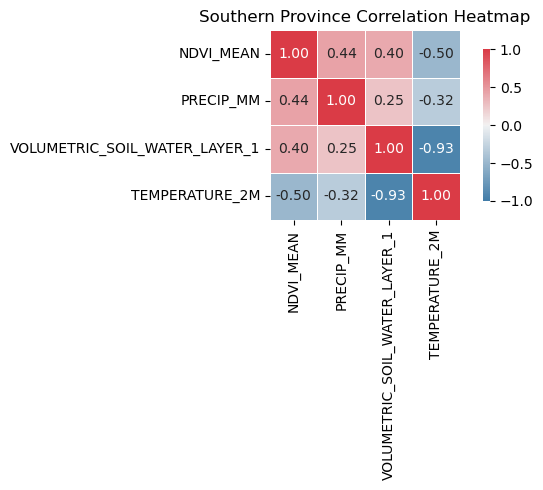

In [126]:
south_corr = southern_df[['NDVI_MEAN', 'PRECIP_MM', 'VOLUMETRIC_SOIL_WATER_LAYER_1', 'TEMPERATURE_2M']].corr()

plt.figure(figsize=(7, 5))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    south_corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Southern Province Correlation Heatmap")
plt.tight_layout()
plt.show()

In [127]:
# Load the climate indices file
df_indices = pd.read_csv(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\climate_merged.csv") 

# Convert 'date' to datetime (letting pandas infer the format automatically)
df_indices['DATE_DT'] = pd.to_datetime(df_indices['date'], errors='coerce')

# Extract Year and Month
df_indices['YEAR'] = df_indices['DATE_DT'].dt.year
df_indices['MONTH'] = df_indices['DATE_DT'].dt.month

# Clean up column names to ensure they match your weather data
df_indices.columns = df_indices.columns.str.strip().str.upper()

# THE JOIN (Make sure 'merged_df' from your previous code is in memory)
# We join on YEAR and MONTH
final_master = pd.merge(merged_df, df_indices[['YEAR', 'MONTH', 'NINO34', 'DMI', 'TSA', 'NAO']], 
                        on=['YEAR', 'MONTH'], how='left')

print("Join Successful! Climate indices are now part of the master table.")
print(final_master[['YEAR', 'MONTH', 'NINO34', 'NDVI_MEAN']].head())

Join Successful! Climate indices are now part of the master table.
   YEAR  MONTH  NINO34  NDVI_MEAN
0  2000      2   -1.55   0.561508
1  2000      2   -1.55   0.562254
2  2000      2   -1.55   0.543531
3  2000      2   -1.55   0.544423
4  2000      2   -1.55   0.453161


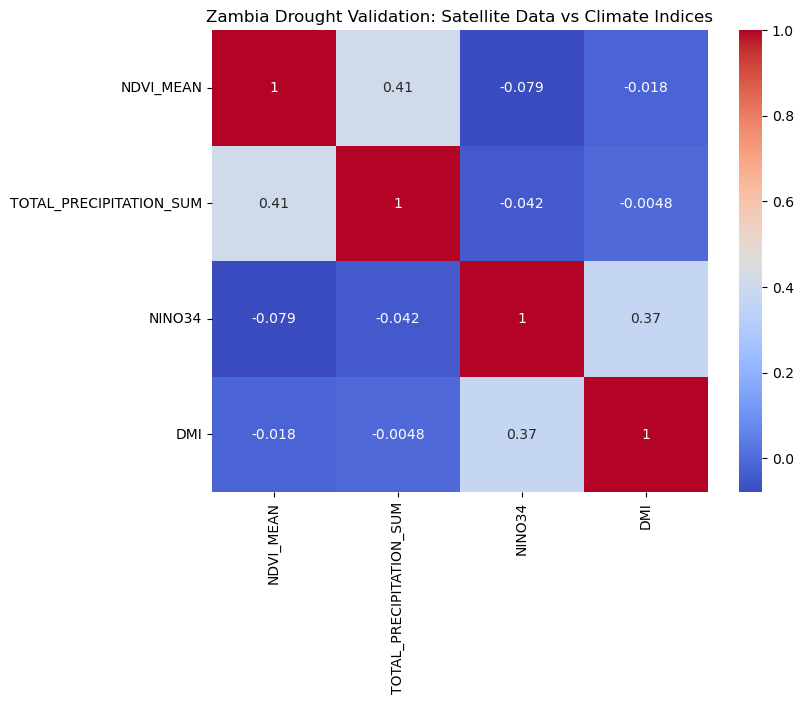

In [128]:
# Calculate correlation between NINO34 and your Vegetation/Rain
# This proves the "Teleconnection" your boss asked for
climate_validation = final_master[['NDVI_MEAN', 'TOTAL_PRECIPITATION_SUM', 'NINO34', 'DMI']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(climate_validation, annot=True, cmap='coolwarm')
plt.title("Zambia Drought Validation: Satellite Data vs Climate Indices")
plt.show()

In [129]:
# --- STEP 1: Filter for the Growing Season Months ---
# We only care about November, December (from the start of the season) 
# and January, February, March, April (the peak growing/rainy period).
growing_months = [11, 12, 1, 2, 3, 4]
df_growing = final_master[final_master['MONTH'].isin(growing_months)].copy()

# --- STEP 2: Create a unique "SEASON" Label ---
# Logic: If the month is Nov/Dec, it belongs to the NEXT year's harvest (e.g., Nov 2015 -> Season 2015-2016).
# If the month is Jan-Apr, it belongs to the CURRENT year's harvest (e.g., Jan 2016 -> Season 2015-2016).
def assign_season(row):
    year = int(row['YEAR'])
    if row['MONTH'] >= 11:
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

df_growing['SEASON'] = df_growing.apply(assign_season, axis=1)

# --- STEP 3: Define the "Weighted Mean" Aggregations ---
# Different variables require different math:
# - Rainfall (PRECIP): Should be SUMMED (total water available for the crop).
# - Indices (NDVI, NINO34, DMI): Should be AVERAGED (the average state of the environment).
agg_logic = {
    'NDVI_MEAN': 'mean',
    'TOTAL_PRECIPITATION_SUM': 'sum',
    'VOLUMETRIC_SOIL_WATER_LAYER_1': 'mean', # Should use Layer 2 (7-28cm) if available
    'NINO34': 'mean',                        # Average ENSO strength during the 6 months
    'DMI': 'mean',                           # Average IOD strength during the 6 months
    'TEMPERATURE_2M': 'mean'
}

# --- STEP 4: Group by District and Season ---
# This converts your daily/monthly data into one single row per district per crop year.
seasonal_summary = df_growing.groupby(['DISTRICT', 'SEASON']).agg(agg_logic).reset_index()

# --- STEP 5: Conversion (Optional but helpful) ---
# Convert Precipitation from meters (ERA5 default) to millimeters
seasonal_summary['PRECIP_MM'] = seasonal_summary['TOTAL_PRECIPITATION_SUM'] * 1000

# --- STEP 6: Final Clean-up and Preview ---
# Sort by District and Season so the time series flows correctly
seasonal_summary = seasonal_summary.sort_values(['DISTRICT', 'SEASON'])

print("Phase 3 Complete: Seasonal Aggregation (Nov-Apr) is finished.")
print(seasonal_summary[['DISTRICT', 'SEASON', 'NINO34', 'PRECIP_MM', 'NDVI_MEAN']].head(10))

# Save the seasonal table for your boss
seasonal_summary.to_csv('Zambia_Seasonal_Drought_Analysis.csv', index=False)

Phase 3 Complete: Seasonal Aggregation (Nov-Apr) is finished.
  DISTRICT     SEASON    NINO34    PRECIP_MM  NDVI_MEAN
0  CHADIZA  1999-2000 -1.045762   775.796114   0.578484
1  CHADIZA  2000-2001 -0.663976  2234.472033   0.560364
2  CHADIZA  2001-2002 -0.158398  1921.700535   0.549534
3  CHADIZA  2002-2003  0.718508  2187.488986   0.517193
4  CHADIZA  2003-2004  0.242253  1807.520724   0.525614
5  CHADIZA  2004-2005  0.512831  1447.788625   0.533124
6  CHADIZA  2005-2006 -0.689503  2408.825786   0.562757
7  CHADIZA  2006-2007  0.415470  2341.749296   0.532918
8  CHADIZA  2007-2008 -1.444505  2126.957748   0.520108
9  CHADIZA  2008-2009 -0.693735  2339.879203   0.567501


In [130]:
# Aggregate District Data to Province Level ---
# We filter for the Southern districts and then group by SEASON 
# to get one single value for the whole province per year.
Zambia_seasonal = seasonal_summary.groupby(['DISTRICT', 'SEASON']).agg({
    'NDVI_MEAN': 'mean',
    'PRECIP_MM': 'mean',
    'NINO34': 'mean',
    'DMI': 'mean'
}).reset_index()



# --- STEP 3: Calculate the "Normal" (Long-term Mean) ---
# This is our baseline to see if El Niño years actually cause a "drop"
Zambia_avg_ndvi = Zambia_seasonal['NDVI_MEAN'].mean()
Zambia_avg_precip = Zambia_seasonal['PRECIP_MM'].mean()

# --- STEP 4: Identify Strong El Niño Seasons (NINO34 > 1.0) ---
Zambia_el_nino_seasons = Zambia_seasonal[Zambia_seasonal['NINO34'] > 1.0]

# --- STEP 4: Identify Strong El Niño Seasons (NINO34 > 1.0) ---
el_nino_seasons = Zambia_el_nino_seasons[Zambia_el_nino_seasons['NINO34'] > 1.0]

print(f"Long-term Average NDVI for Southern Province: {Zambia_avg_ndvi:.4f}")
print("-" * 30)
print("Analysis of Strong El Niño Years (> 1.0):")
print(el_nino_seasons[['SEASON', 'NINO34', 'NDVI_MEAN', 'PRECIP_MM']])

Long-term Average NDVI for Southern Province: 0.5895
------------------------------
Analysis of Strong El Niño Years (> 1.0):
         SEASON    NINO34  NDVI_MEAN    PRECIP_MM
10    2009-2010  1.210829   0.529389  2233.071388
16    2015-2016  2.125220   0.512510  1531.663159
24    2023-2024  2.025000   0.352993   395.438441
35    2009-2010  1.210829   0.601610  2302.265348
41    2015-2016  2.125220   0.587988  2290.086002
...         ...       ...        ...          ...
1816  2015-2016  2.125220   0.619454  2661.107770
1824  2023-2024  2.025000   0.599189   775.601410
1835  2009-2010  1.210829   0.635760  2476.998542
1841  2015-2016  2.125220   0.663362  2511.978085
1849  2023-2024  2.025000   0.657526   717.112258

[222 rows x 4 columns]


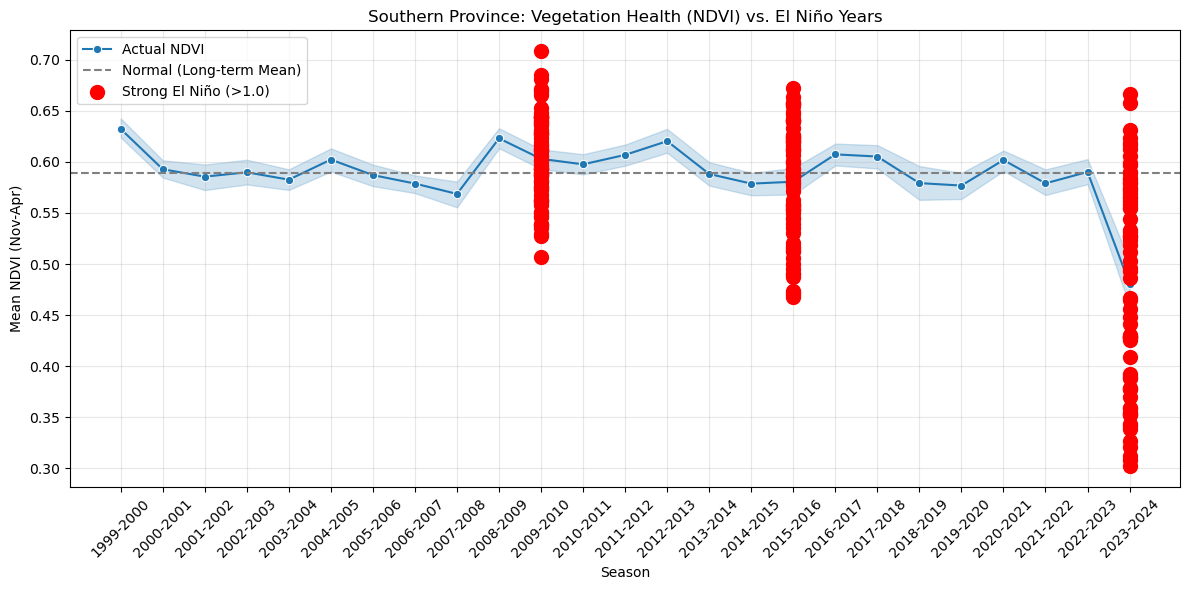


Correlation between NINO34 and NDVI: -0.24
WEAK CORRELATION: The relationship is not as strong as expected.


In [131]:
# --- STEP 5: Visual Validation (The 2015/2016 Check) ---
# Let's plot the NDVI over time and highlight the El Niño years in Red
plt.figure(figsize=(12, 6))

# Plot the NDVI time series
sns.lineplot(data=Zambia_seasonal, x='SEASON', y='NDVI_MEAN', marker='o', label='Actual NDVI')

# Add a horizontal line for the "Normal" average
plt.axhline(Zambia_avg_ndvi, color='gray', linestyle='--', label='Normal (Long-term Mean)')

# Highlight El Niño years (NINO34 > 1.0) with red dots
Zambia_strong_nino = Zambia_seasonal[Zambia_seasonal['NINO34'] > 1.0]
plt.scatter(Zambia_strong_nino['SEASON'], Zambia_strong_nino['NDVI_MEAN'], color='red', s=100, zorder=5, label='Strong El Niño (>1.0)')

# Formatting the plot
plt.xticks(rotation=45)
plt.title("Southern Province: Vegetation Health (NDVI) vs. El Niño Years")
plt.ylabel("Mean NDVI (Nov-Apr)")
plt.xlabel("Season")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- STEP 6: Final Physical Correlation Check ---
Zambia_correlation = Zambia_seasonal['NINO34'].corr(Zambia_seasonal['NDVI_MEAN'])
print(f"\nCorrelation between NINO34 and NDVI: {Zambia_correlation:.2f}")

if Zambia_correlation < -0.4:
    print("VALIDATED: There is a strong negative correlation. When NINO34 goes UP, NDVI goes DOWN.")
else:
    print("WEAK CORRELATION: The relationship is not as strong as expected.")

In [132]:
# --- STEP 1: Calculate Anomalies for ALL Districts ---
# We calculate how each district performed compared to its own historical average
district_stats = seasonal_summary.groupby('DISTRICT')[['NDVI_MEAN', 'PRECIP_MM']].transform('mean')
seasonal_summary['NDVI_Anomaly_%'] = (seasonal_summary['NDVI_MEAN'] - district_stats['NDVI_MEAN']) / district_stats['NDVI_MEAN'] * 100
seasonal_summary['Rain_Anomaly_%'] = (seasonal_summary['PRECIP_MM'] - district_stats['PRECIP_MM']) / district_stats['PRECIP_MM'] * 100

# --- STEP 2: The Helper Function (FIXED) ---
def get_worst_districts(group):
    # Sort by NDVI Anomaly (most negative first)
    worst = group.sort_values(by='NDVI_Anomaly_%').head(3)
    
    # FIX: Added .iterrows() so Python can unpack the index and the row
    items = []
    for index, row in worst.iterrows():
        items.append(f"{row['DISTRICT']} ({row['NDVI_Anomaly_%']:.1f}%)")
    
    return ", ".join(items)

# Apply the function to get the "Guilty" districts for every season
worst_districts_per_season = seasonal_summary.groupby('SEASON').apply(get_worst_districts).reset_index()
worst_districts_per_season.columns = ['SEASON', 'Hardest_Hit_Districts']

# --- STEP 3: Create the National Zambia Summary ---
# This aggregates all districts in the country into one national average per season
zambia_national_seasonal = seasonal_summary.groupby('SEASON').agg({
    'NDVI_MEAN': 'mean',
    'PRECIP_MM': 'mean',
    'NDVI_Anomaly_%': 'mean',
    'Rain_Anomaly_%': 'mean',
    'NINO34': 'first', # Climate indices are global for Zambia
    'DMI': 'first'
}).reset_index()

# Merge the district names back into the national table
zambia_report = pd.merge(zambia_national_seasonal, worst_districts_per_season, on='SEASON')

# --- STEP 4: Impact Status Logic ---
def get_impact_label(row):
    if row['NINO34'] >= 0.8 and row['NDVI_Anomaly_%'] < -4:
        return "⚠️ Severe El Niño Drought"
    elif row['NINO34'] >= 0.5:
        return "🔸 Mild El Niño Impact"
    elif row['NINO34'] <= -0.5:
        return "🔹 La Niña (Wet/Normal)"
    else:
        return "✅ Neutral/Normal"

zambia_report['Climate Status'] = zambia_report.apply(get_impact_label, axis=1)

# --- STEP 5: Create and Style the HTML Table ---
final_report = zambia_report[[
    'SEASON', 'NINO34', 'NDVI_Anomaly_%', 'Rain_Anomaly_%', 'Climate Status', 'Hardest_Hit_Districts'
]].copy()

final_report.columns = [
    'Season', 'NINO34 Index', 'Zambia NDVI Anomaly', 'Zambia Rain Anomaly', 'Climate Status', 'Hardest Hit Districts (Top 3)'
]

styled_zambia_table = final_report.style.format({
    'NINO34 Index': '{:.2f}',
    'Zambia NDVI Anomaly': '{:+.1f}%',
    'Zambia Rain Anomaly': '{:+.1f}%'
}).background_gradient(
    subset=['NINO34 Index'], cmap='coolwarm'
).background_gradient(
    subset=['Zambia NDVI Anomaly'], cmap='RdYlGn', vmin=-10, vmax=10
).set_caption(
    "<b>Zambia National Drought Validation & District Impact (2000-2024)</b>"
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('padding', '10px'), ('border', '1px solid #dee2e6')]}
])

# Save outputs
try:
    with open("Zambia_National_Drought_Report.html", "w", encoding="utf-8") as f:
        f.write(styled_zambia_table.to_html())
    final_report.to_csv("Zambia_National_Report.csv", index=False)
    print("✅ Files saved successfully: 'Zambia_National_Drought_Report.html' and 'Zambia_National_Report.csv'")
except Exception as e:
    print(f"❌ Error saving: {e}")

# Display for you to see


✅ Files saved successfully: 'Zambia_National_Drought_Report.html' and 'Zambia_National_Report.csv'


C:\Users\flavi\AppData\Local\Temp\ipykernel_17052\3062847505.py:20: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [133]:
# Select and Rename for professional output
final_report = zambia_report[[
    'SEASON', 'NINO34', 'NDVI_Anomaly_%', 'Rain_Anomaly_%', 'Climate Status', 'Hardest_Hit_Districts'
]]

final_report.columns = [
    'Season', 'NINO34 Index', 'National NDVI Anomaly', 'National Rain Anomaly', 'Climate Status', 'Hardest Hit Districts (Top 3)'
]

# Apply Styling
styled_zambia_table = final_report.style.format({
    'NINO34 Index': '{:.2f}',
    'National NDVI Anomaly': '{:+.1f}%',
    'National Rain Anomaly': '{:+.1f}%'
}).background_gradient(
    subset=['NINO34 Index'], cmap='coolwarm'
).background_gradient(
    subset=['National NDVI Anomaly'], cmap='RdYlGn', vmin=-15, vmax=15
).set_caption(
    "<b>Table 1: Zambia National Drought Validation & District Impact (Nov-Apr)</b>"
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white')]}
])

# Save output
with open("Zambia_National_Drought_Report.html", "w", encoding="utf-8") as f:
    f.write(styled_zambia_table.to_html())

print("✅ National Report Saved!")

✅ National Report Saved!


In [134]:
# --- STEP 1: Define Southern Province Districts ---
# --- STEP 2: Aggregate District Data to Province Level ---
# We filter for the Southern districts and then group by SEASON 
# to get one single value for the whole province per year.
southern_province_seasonal = seasonal_summary[
    seasonal_summary['DISTRICT'].isin(southern_districts)
].groupby('SEASON').agg({
    'NDVI_MEAN': 'mean',
    'PRECIP_MM': 'mean',
    'NINO34': 'mean',
    'DMI': 'mean'
}).reset_index()

# --- STEP 3: Calculate the "Normal" (Long-term Mean) ---
# This is our baseline to see if El Niño years actually cause a "drop"
avg_ndvi = southern_province_seasonal['NDVI_MEAN'].mean()
avg_precip = southern_province_seasonal['PRECIP_MM'].mean()

# --- STEP 4: Identify Strong El Niño Seasons (NINO34 > 1.0) ---
el_nino_seasons = southern_province_seasonal[southern_province_seasonal['NINO34'] > 1.0]

print(f"Long-term Average NDVI for Southern Province: {avg_ndvi:.4f}")
print("-" * 30)
print("Analysis of Strong El Niño Years (> 1.0):")
print(el_nino_seasons[['SEASON', 'NINO34', 'NDVI_MEAN', 'PRECIP_MM']])

Long-term Average NDVI for Southern Province: 0.5253
------------------------------
Analysis of Strong El Niño Years (> 1.0):
       SEASON    NINO34  NDVI_MEAN    PRECIP_MM
10  2009-2010  1.210829   0.555478  2194.268469
16  2015-2016  2.125220   0.496486  1694.784233
24  2023-2024  2.025000   0.352021   416.950321


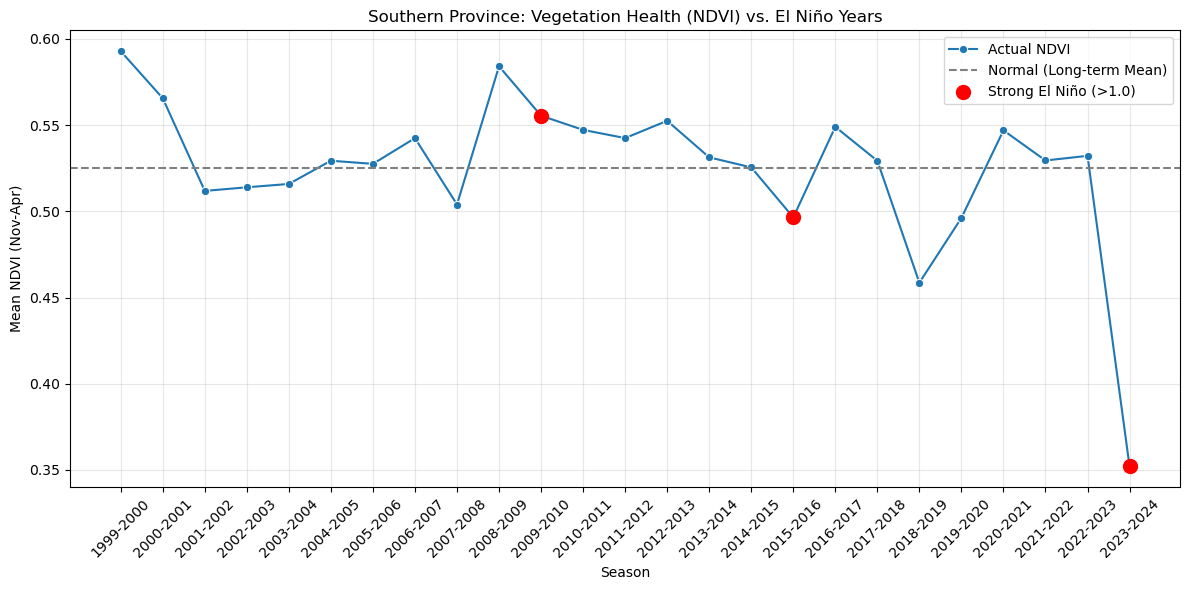


Correlation between NINO34 and NDVI: -0.60
VALIDATED: There is a strong negative correlation. When NINO34 goes UP, NDVI goes DOWN.


In [135]:
# --- STEP 5: Visual Validation (The 2015/2016 Check) ---
# Let's plot the NDVI over time and highlight the El Niño years in Red
plt.figure(figsize=(12, 6))

# Plot the NDVI time series
sns.lineplot(data=southern_province_seasonal, x='SEASON', y='NDVI_MEAN', marker='o', label='Actual NDVI')

# Add a horizontal line for the "Normal" average
plt.axhline(avg_ndvi, color='gray', linestyle='--', label='Normal (Long-term Mean)')

# Highlight El Niño years (NINO34 > 1.0) with red dots
strong_nino = southern_province_seasonal[southern_province_seasonal['NINO34'] > 1.0]
plt.scatter(strong_nino['SEASON'], strong_nino['NDVI_MEAN'], color='red', s=100, zorder=5, label='Strong El Niño (>1.0)')

# Formatting the plot
plt.xticks(rotation=45)
plt.title("Southern Province: Vegetation Health (NDVI) vs. El Niño Years")
plt.ylabel("Mean NDVI (Nov-Apr)")
plt.xlabel("Season")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- STEP 6: Final Physical Correlation Check ---
correlation = southern_province_seasonal['NINO34'].corr(southern_province_seasonal['NDVI_MEAN'])
print(f"\nCorrelation between NINO34 and NDVI: {correlation:.2f}")

if correlation < -0.4:
    print("VALIDATED: There is a strong negative correlation. When NINO34 goes UP, NDVI goes DOWN.")
else:
    print("WEAK CORRELATION: The relationship is not as strong as expected.")

In [136]:
# --- STEP 1: Prepare the Report DataFrame ---
# Calculate Anomalies (Percentage deviation from normal)
# This is what publishers/bosses want to see: "How much worse was it than average?"
southern_province_seasonal['NDVI_Anomaly_%'] = (
    (southern_province_seasonal['NDVI_MEAN'] - avg_ndvi) / avg_ndvi * 100
)
southern_province_seasonal['Rain_Anomaly_%'] = (
    (southern_province_seasonal['PRECIP_MM'] - avg_precip) / avg_precip * 100
)

# Create a "Status" column for quick reading
def get_impact_label(row):
    if row['NINO34'] >= 1.0 and row['NDVI_Anomaly_%'] < -5:
        return "⚠️ Severe El Niño Drought"
    elif row['NINO34'] >= 0.5:
        return "🔸 Mild El Niño Impact"
    elif row['NINO34'] <= -0.5:
        return "🔹 La Niña (Wet)"
    else:
        return "✅ Neutral/Normal"

southern_province_seasonal['Impact_Status'] = southern_province_seasonal.apply(get_impact_label, axis=1)

# Select and Rename columns for a professional look
report_df = southern_province_seasonal[[
    'SEASON', 'NINO34', 'NDVI_MEAN', 'NDVI_Anomaly_%', 'PRECIP_MM', 'Rain_Anomaly_%', 'Impact_Status'
]].copy()

report_df.columns = [
    'Season', 'NINO34 Index', 'Mean NDVI', 'NDVI Anomaly (%)', 
    'Total Rain (mm)', 'Rain Anomaly (%)', 'Climate Status'
]

# --- STEP 2: Apply Professional Styling ---
# We use a color gradient: Red for low NDVI/Rain, Blue/Red for NINO34
styled_table = report_df.style.format({
    'NINO34 Index': '{:.2f}',
    'Mean NDVI': '{:.3f}',
    'NDVI Anomaly (%)': '{:+.1f}%',
    'Total Rain (mm)': '{:.1f}',
    'Rain Anomaly (%)': '{:+.1f}%'
}).background_gradient(
    subset=['NINO34 Index'], cmap='coolwarm', vmin=-2, vmax=2
).background_gradient(
    subset=['NDVI Anomaly (%)'], cmap='RdYlGn', vmin=-15, vmax=15
).background_gradient(
    subset=['Rain Anomaly (%)'], cmap='RdBu', vmin=-40, vmax=40
).set_caption(
    "<b>Table 1: Southern Province Drought Validation & Teleconnection Analysis (2000-Present)</b>"
).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-family', 'Arial')]},
    {'selector': 'td', 'props': [('font-family', 'Arial'), ('font-size', '12px')]}
])

# --- STEP 3: Display and Export ---
# 1. Display in your Notebook (if using Jupyter/Spyder/VS Code)
from IPython.display import display
display(styled_table)

# 2. Save as HTML with UTF-8 encoding (This fixes your UnicodeEncodeError)
try:
    with open("Southern_Province_Drought_Report.html", "w", encoding="utf-8") as f:
        f.write(styled_table.to_html())
    print("Saved as 'Southern_Province_Drought_Report.html'")
except Exception as e:
    print(f"❌ Error saving file: {e}")

# 3. Optional: Save a 'Clean' CSV version for Excel users
report_df.to_csv("Zambia_Drought_Validation_Report.csv", index=False, encoding='utf-8-sig')

,Season,NINO34 Index,Mean NDVI,NDVI Anomaly (%),Total Rain (mm),Rain Anomaly (%),Climate Status
0,1999-2000,-1.05,0.593,+12.9%,647.0,-63.2%,🔹 La Niña (Wet)
1,2000-2001,-0.66,0.566,+7.7%,1947.9,+10.8%,🔹 La Niña (Wet)
2,2001-2002,-0.16,0.512,-2.6%,1230.4,-30.0%,✅ Neutral/Normal
3,2002-2003,0.72,0.514,-2.2%,1794.7,+2.1%,🔸 Mild El Niño Impact
4,2003-2004,0.24,0.516,-1.8%,1878.1,+6.9%,✅ Neutral/Normal
5,2004-2005,0.51,0.529,+0.8%,1159.2,-34.0%,🔸 Mild El Niño Impact
6,2005-2006,-0.69,0.528,+0.4%,2193.9,+24.8%,🔹 La Niña (Wet)
7,2006-2007,0.42,0.542,+3.3%,1758.2,+0.0%,✅ Neutral/Normal
8,2007-2008,-1.44,0.504,-4.1%,2450.8,+39.4%,🔹 La Niña (Wet)
9,2008-2009,-0.69,0.584,+11.2%,2083.0,+18.5%,🔹 La Niña (Wet)


Saved as 'Southern_Province_Drought_Report.html'


In [137]:
Zamb_districts_gdf = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_Administrative_Boundaries_Districts_2020_-7037893626831916322\NSDI_Zambia_Districts_2022.shp")

In [138]:
#Zamb_districts_rename = Zamb_districts_gdf.rename(columns={"DISTRICT":"ADMIN_NAME"})
Zamb_districts_gdf.head()

,FEATURE_TY,PROVINCE,Area_km,PROV_CODE,DIST_CODE,DISTRICT,geometry
0,District Town,Eastern,1612.440783,103,103001,Chadiza,"POLYGON ((3644994.895 -1571613.69, 3644992.249..."
1,District Town,Eastern,17446.739460,103,106001,Chama,"POLYGON ((3672326.658 -1156774.326, 3672341.71..."
2,District Town,Eastern,2959.348726,103,103010,Chasefu,"POLYGON ((3708174.203 -1373531.644, 3707774.77..."
3,District Town,North-Western,4859.529189,108,108001,Chavuma,"POLYGON ((2573156.925 -1458928.358, 2573156.96..."
4,District Town,Luapula,2160.206376,104,104001,Chembe,"POLYGON ((3211140.971 -1290880.299, 3211170.69..."


In [139]:
seasonal_summary["DISTRICT"] = seasonal_summary["DISTRICT"].str.capitalize()
seasonal_summary.head()

,DISTRICT,SEASON,NDVI_MEAN,TOTAL_PRECIPITATION_SUM,VOLUMETRIC_SOIL_WATER_LAYER_1,NINO34,DMI,TEMPERATURE_2M,PRECIP_MM,NDVI_Anomaly_%,Rain_Anomaly_%
0,Chadiza,1999-2000,0.578484,0.775796,0.420604,-1.045762,0.111781,293.903454,775.796114,8.996828,-60.300852
1,Chadiza,2000-2001,0.560364,2.234472,0.426285,-0.663976,-0.134608,294.289575,2234.472033,5.582739,14.342719
2,Chadiza,2001-2002,0.549534,1.921701,0.375412,-0.158398,-0.145796,295.195520,1921.700535,3.542178,-1.662468
3,Chadiza,2002-2003,0.517193,2.187489,0.373128,0.718508,-0.072541,295.141705,2187.488986,-2.551460,11.938496
4,Chadiza,2003-2004,0.525614,1.807521,0.370645,0.242253,0.031571,295.470823,1807.520724,-0.964909,-7.505294


In [140]:
growing_season.head()

,DATE_WEATHER,DISTRICT,PCODE_WEATHER,TEMPERATURE_2M,VOLUMETRIC_SOIL_WATER_LAYER_1,TOTAL_PRECIPITATION_SUM,TEMPERATURE_2M_MIN,TEMPERATURE_2M_MAX,DATE_DT_WEATHER,YEAR,...,DATE_NDVI,GLAD_YEAR,PCODE_NDVI,NDVI_MEAN,NDVI_MEDIAN,NDVI_MODE,EVI_MEAN,EVI_MEDIAN,EVI_MODE,DATE_DT_NDVI
0,01/02/2000,CHIBOMBO,ZM2011A20101,295.170080,0.407170,0.007191,291.329880,299.456595,2000-02-01,2000,...,18-02-00,2003,ZM2011A20101,0.561508,0.580193,0.619067,0.378623,0.384674,0.388794,2000-02-18
1,01/02/2000,KABWE,ZM2011A20105,294.584165,0.396189,0.008825,290.412274,298.944192,2000-02-01,2000,...,18-02-00,2003,ZM2011A20105,0.562254,0.580710,0.631446,0.395002,0.380832,0.388794,2000-02-18
2,01/02/2000,KAPIRI MPOSHI,ZM2011A20106,294.949747,0.391187,0.008080,291.349517,299.868142,2000-02-01,2000,...,18-02-00,2003,ZM2011A20106,0.543531,0.560810,0.724795,0.368682,0.376884,0.376884,2000-02-18
3,01/02/2000,MKUSHI,ZM2011A20110,294.594358,0.386953,0.009538,291.560583,298.239022,2000-02-01,2000,...,18-02-00,2003,ZM2011A20110,0.544423,0.595528,0.650417,0.372618,0.388788,0.388788,2000-02-18
4,01/02/2000,SERENJE,ZM2011A20111,293.605896,0.416076,0.014858,291.122148,297.012737,2000-02-01,2000,...,18-02-00,2003,ZM2011A20111,0.453161,0.428063,0.673860,0.312187,0.293411,0.263507,2000-02-18


In [141]:
Zamb_districts_4326 = Zamb_districts_gdf.to_crs(epsg=4326)
print("Zamb_districts_4326 CRS:", Zamb_districts_4326.crs)
gdf_merged = seasonal_summary.merge(Zamb_districts_4326, on='DISTRICT', how='left')

Zamb_districts_4326 CRS: EPSG:4326


In [142]:
gdf_merged.head()

,DISTRICT,SEASON,NDVI_MEAN,TOTAL_PRECIPITATION_SUM,VOLUMETRIC_SOIL_WATER_LAYER_1,NINO34,DMI,TEMPERATURE_2M,PRECIP_MM,NDVI_Anomaly_%,Rain_Anomaly_%,FEATURE_TY,PROVINCE,Area_km,PROV_CODE,DIST_CODE,geometry
0,Chadiza,1999-2000,0.578484,0.775796,0.420604,-1.045762,0.111781,293.903454,775.796114,8.996828,-60.300852,District Town,Eastern,1612.440783,103.0,103001.0,"POLYGON ((32.74355 -13.97731, 32.74352 -13.977..."
1,Chadiza,2000-2001,0.560364,2.234472,0.426285,-0.663976,-0.134608,294.289575,2234.472033,5.582739,14.342719,District Town,Eastern,1612.440783,103.0,103001.0,"POLYGON ((32.74355 -13.97731, 32.74352 -13.977..."
2,Chadiza,2001-2002,0.549534,1.921701,0.375412,-0.158398,-0.145796,295.195520,1921.700535,3.542178,-1.662468,District Town,Eastern,1612.440783,103.0,103001.0,"POLYGON ((32.74355 -13.97731, 32.74352 -13.977..."
3,Chadiza,2002-2003,0.517193,2.187489,0.373128,0.718508,-0.072541,295.141705,2187.488986,-2.551460,11.938496,District Town,Eastern,1612.440783,103.0,103001.0,"POLYGON ((32.74355 -13.97731, 32.74352 -13.977..."
4,Chadiza,2003-2004,0.525614,1.807521,0.370645,0.242253,0.031571,295.470823,1807.520724,-0.964909,-7.505294,District Town,Eastern,1612.440783,103.0,103001.0,"POLYGON ((32.74355 -13.97731, 32.74352 -13.977..."


In [ ]:
# 1. Aggregate District data up to the 10 Provinces
# Note: Ensure your CSV has the 'ADM1_NAME' (Province) column
province_time_series = seasonal_summary.groupby(['DISTRICT', 'SEASON']).agg({
    'NDVI_MEAN': 'mean',
    'PRECIP_MM': 'mean',
    'VOLUMETRIC_SOIL_WATER_LAYER_1': 'mean',
    'TEMPERATURE_2M': 'mean',
    'NINO34': 'first' # ENSO is the same for the whole country
}).reset_index()

# 2. Calculate the 'Big Picture' Indices (SSI and VHI)
# SSI Calculation (Standardized Soil Moisture)
province_time_series['SSI'] = (province_time_series['VOLUMETRIC_SOIL_WATER_LAYER_1'] - 
                               province_time_series['VOLUMETRIC_SOIL_WATER_LAYER_1'].mean()) / \
                               province_time_series['VOLUMETRIC_SOIL_WATER_LAYER_1'].std()

# Save this as your "Big Picture" CSV
province_time_series.to_csv('Zambia_10_Provinces_TimeSeries.csv', index=False)

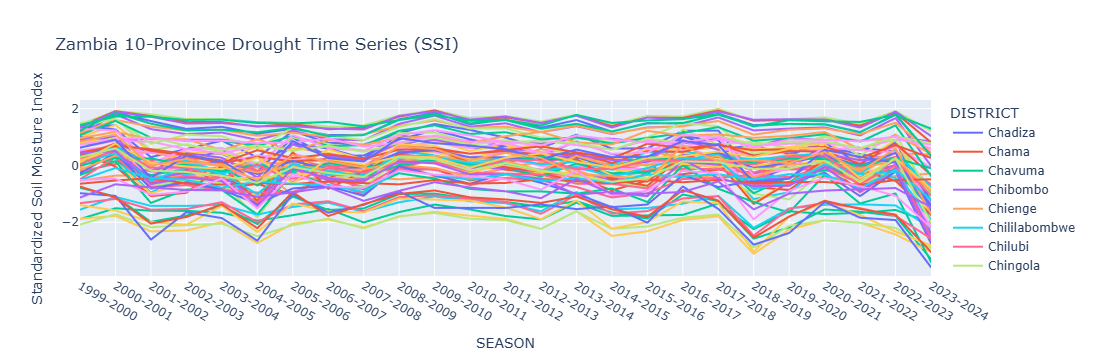

HTML Time Series Created!


In [150]:
import plotly.express as px

# 1. Create the Line Chart for VHI/SSI
fig = px.line(province_time_series, 
              x="SEASON", 
              y="SSI", 
              color="DISTRICT",
              title="Zambia 10-Province Drought Time Series (SSI)",
              labels={"CROP_YEAR_LABEL": "Season", "SSI": "Standardized Soil Moisture Index"})

# 2. Add Background Shading for El Niño (Requested in Phase 6)
# Find years where NINO34 > 1.0
el_nino_years = province_time_series[province_time_series['NINO34'] > 1.0]['SEASON'].unique()

for year in el_nino_years:
    fig.add_vrect(x0=year, x1=year, fillcolor="red", opacity=0.2, layer="below", line_width=0)

# 3. Save as the HTML file your boss requested
fig.write_html("Zambia_Provinces_Drought_TimeSeries.html")

# --- STEP 3: Display and Export ---
# 1. Display in your Notebook (if using Jupyter/Spyder/VS Code)
from IPython.display import display
display(fig)
print("HTML Time Series Created!")

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.express as px

# ==========================================
# 1. LOAD AND PREP TABULAR DATA
# ==========================================
df_weather.columns = df_weather.columns.str.strip().str.upper()
df_ndvi.columns = df_ndvi.columns.str.strip().str.upper()

# Fix District Column Name to 'DISTRICT'
def fix_col_names(df):
    for col in df.columns:
        if 'ADM' in col or 'NAM' in col:
            df = df.rename(columns={col: 'DISTRICT'})
    df['DISTRICT'] = df['DISTRICT'].astype(str).str.strip().str.upper()
    return df

df_weather = fix_col_names(df_weather)
df_ndvi = fix_col_names(df_ndvi)

# Fix Dates and create SEASON
df_weather['DATE_DT'] = pd.to_datetime(df_weather['DATE'], dayfirst=True, errors='coerce')
df_weather['YEAR'] = df_weather['DATE_DT'].dt.year
df_weather['MONTH'] = df_weather['DATE_DT'].dt.month

# Filter for Growing Season (Nov-Apr)
df_growing = df_weather[df_weather['MONTH'].isin([11, 12, 1, 2, 3, 4])].copy()
df_growing['CROP_YEAR'] = np.where(df_growing['MONTH'] >= 11, df_growing['YEAR'], df_growing['YEAR'] - 1)
df_growing['SEASON'] = df_growing['CROP_YEAR'].astype(str) + "-" + (df_growing['CROP_YEAR'] + 1).astype(str)

# Calculate Seasonal Mean for SSI
seasonal_summary = df_growing.groupby(['DISTRICT', 'SEASON'])['VOLUMETRIC_SOIL_WATER_LAYER_1'].mean().reset_index()

# CALCULATE SSI (Z-Score)
stats = seasonal_summary.groupby('DISTRICT')['VOLUMETRIC_SOIL_WATER_LAYER_1'].agg(['mean', 'std']).reset_index()
seasonal_summary = seasonal_summary.merge(stats, on='DISTRICT')
seasonal_summary['SSI'] = (seasonal_summary['VOLUMETRIC_SOIL_WATER_LAYER_1'] - seasonal_summary['mean']) / seasonal_summary['std']

# ==========================================
# 2. LOAD GEOMETRY (SHAPEFILE)
# ==========================================
# Load your Zambia District Shapefile
# Replace with your actual .shp file path
zambia_shp = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_Administrative_Boundaries_Districts_2020_-7037893626831916322\NSDI_Zambia_Districts_2022.shp") 
zambia_shp = fix_col_names(zambia_shp) # Ensure 'DISTRICT' column exists and is uppercase

# Merge Tabular Data with Shapefile
gdf_merged = zambia_shp.merge(seasonal_summary, on='DISTRICT')

# Ensure CRS is correct for Plotly (WGS84)
if gdf_merged.crs != "EPSG:4326":
    gdf_merged = gdf_merged.to_crs(epsg=4326)

# Simplify geometry to speed up the map
gdf_merged['geometry'] = gdf_merged.geometry.simplify(0.005)

# ==========================================
# 3. ANIMATED CHOROPLETH MAP
# ==========================================
fig = px.choropleth(
    gdf_merged,
    geojson=gdf_merged.__geo_interface__,
    locations='DISTRICT',             # Column in gdf_merged
    featureidkey="properties.DISTRICT", # Path to the ID inside the GeoJSON
    color="SSI",
    animation_frame="SEASON", 
    hover_name="DISTRICT",     
    color_continuous_scale="RdBu", 
    range_color=[-2.5, 2.5],    
    title="Zambia: Evolution of Soil Moisture Drought (SSI) 2000-2024"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.write_html("Zambia_Drought_Animation.html")
fig.show()

In [ ]:
# ==========================================
# 4. SOUTHERN PROVINCE TRENDS (FACETED)
# ==========================================
# CORRECTED LIST WITH COMMAS
southern_districts = [
    "CHIKANKATA", "CHIRUNDU", "CHOMA", "GWEMBE", "ITEZHI-TEZHI",
    "KALOMO", "KAZUNGULA", "LIVINGSTONE", "MAZABUKA", "MONZE",
    "NAMWALA", "PEMBA", "SIAVONGA", "SINAZONGWE", "ZIMBA"
]

gdf_south = seasonal_summary[seasonal_summary['DISTRICT'].isin(southern_districts)]

# Check if data exists before plotting
if gdf_south.empty:
    print("Warning: Southern Province data is empty. Check District name spelling.")
else:
    fig_facet = px.line(gdf_south, 
                        x="SEASON", 
                        y="SSI", 
                        facet_col="DISTRICT", 
                        facet_col_wrap=4, 
                        title="Southern Province: Drought Trends by District")

    fig_facet.update_xaxes(tickangle=45)
    fig_facet.write_html("Southern_Districts_Trends.html")
    fig_facet.show()

In [ ]:
import geopandas as gpd
import plotly.express as px
import pandas as pd

# 1. Ensure the data is a GeoDataFrame (fixes the 'simplify' error)
gdf_merged = gpd.GeoDataFrame(gdf_merged, geometry='geometry')

# 2. CALCULATE SSI (fixes the 'Value of y is not the name of a column' error)
# We calculate SSI per DISTRICT by standardizing the soil moisture
district_means = gdf_merged.groupby('DISTRICT')['VOLUMETRIC_SOIL_WATER_LAYER_1'].transform('mean')
district_stds = gdf_merged.groupby('DISTRICT')['VOLUMETRIC_SOIL_WATER_LAYER_1'].transform('std')
gdf_merged['SSI'] = (gdf_merged['VOLUMETRIC_SOIL_WATER_LAYER_1'] - district_means) / district_stds

# 3. Simplify the geometry to make the file faster
gdf_merged['geometry'] = gdf_merged.geometry.simplify(0.01)
geojson = gdf_merged.__geo_interface__

# 4. Create the Animated Choropleth Map
fig = px.choropleth(
    gdf_merged,
    geojson=geojson,
    locations=gdf_merged.index,
    color="SSI",
    animation_frame="SEASON", 
    hover_name="DISTRICT",     
    color_continuous_scale="RdBu", 
    range_color=[-2.5, 2.5],    
    title="Zambia: Evolution of Agricultural Drought by District (2000-2024)",
    labels={'SSI': 'Drought Index (SSI)'}
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.write_html("Zambia_Drought_Animation.html")
fig.show()

# 5. Create the Faceted Trends (Small Multiples)
# IMPORTANT: Zambia has ~116 districts. 116 charts is too messy!
# We filter for only the SOUTHERN PROVINCE to keep this clean as requested.
gdf_south = gdf_merged[gdf_merged['DISTRICT'].isin(southern_districts)]

fig_facet = px.line(gdf_south, 
                    x="SEASON", 
                    y="SSI", 
                    facet_col="DISTRICT", 
                    facet_col_wrap=4, 
                    title="Southern Province: Drought Trends by District")

fig_facet.update_xaxes(tickangle=45)
fig_facet.write_html("Southern_Districts_Trends.html")
fig_facet.show()

In [ ]:
# "Small Multiples" - 10 clean charts in one view
fig_facet = px.line(gdf_merge, 
                    x="SEASON", 
                    y="SSI", 
                    facet_col="DISTRICT", 
                    facet_col_wrap=5, # 2 rows of 5 provinces
                    title="Zambia Drought Trends by Province")

fig_facet.write_html("Zambia_Province_Trends_Grid.html")